In [1]:
import numpy as np
import pymanopt
import matplotlib.pyplot as plt
from wang import cpd_spd_wang, cpd_grassmann_wang, adaptive_threshold
from wang import generate_random_mtx_normal, generate_random_SPD_mtx, generate_random_SPD_Wishart

np.random.seed(123)

In [2]:
# parameter settings
lambda_0 = 1e-2
lambda_1 = 2e-2

In [3]:
# experiment setups
T = 2000
Tc = 1000

In [4]:
N = 20 # Dimension of the ambient space.
P = 5 # Dimension of the subspaces.

# generate parameters for two matrix normal distributions
temp = np.random.randn(N,N)
eigsv = np.random.rand(N) + 1e-6 # positive
U = generate_random_SPD_mtx(temp, eigsv)
temp = np.random.randn(N,N)
eigsv = np.random.rand(N) + 1e-6 # positive
V = generate_random_SPD_mtx(temp, eigsv)
M0 = np.random.randn(N,N) + 1
M1 = M0 + 0.03 * np.random.randn(N,N)

manifold = pymanopt.manifolds.grassmann.Grassmann(N, P)
X = []
for t in range(T):
    if t < Tc:
        temp = generate_random_mtx_normal(M0, U, V)
        X.append(np.linalg.svd(temp)[0][:, :P]) # Truncated SVD 
    else:
        temp = generate_random_mtx_normal(M1, U, V)
        X.append(np.linalg.svd(temp)[0][:, :P]) # Truncated SVD

stats_a = cpd_grassmann_wang(manifold, X, lambda_0, lambda_1)

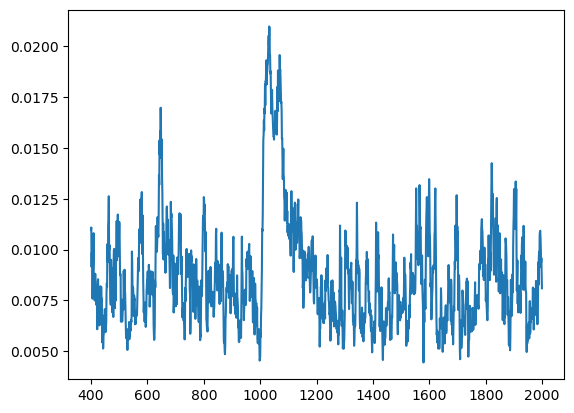

In [5]:
plt.plot(range(400, len(stats_a)), stats_a[400:])

In [15]:
threshold = adaptive_threshold(stats_a, alpha=0.25, a=1.6)

chpnts = []
for i in range(T):
    if stats_a[i] > threshold[i]:
        chpnts.append(i)

print(chpnts)

[0, 1, 2, 217, 545, 934, 1374, 1552, 1776]


In [7]:
N = 2 # Dimension of the space

# generate parameters for two Wishart distributions
np.random.seed(1)
temp = np.random.randn(N,N)
eigsv = np.random.rand(N) + 1e-6 # positive
eigsv_v = 1.6 * np.random.rand(1)
M0 = generate_random_SPD_mtx(temp, eigsv)
M1 = generate_random_SPD_mtx(temp, eigsv + eigsv_v)

manifold = pymanopt.manifolds.positive_definite.SymmetricPositiveDefinite(N)
X = []
for t in range(T):
    if t < Tc:
        X.append(generate_random_SPD_Wishart(N+3, M0))
    else:
        X.append(generate_random_SPD_Wishart(N+3, M1))
stats = cpd_spd_wang(manifold, X, lambda_0, lambda_1)

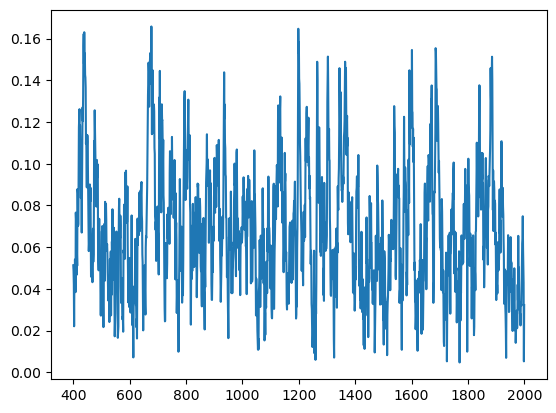

In [8]:
plt.plot(range(400, len(stats)), stats[400:])

In [9]:
threshold = adaptive_threshold(stats, alpha=0.2, a=1.8)

chpnts = []
for i in range(T):
    if stats[i] > threshold[i]:
        chpnts.append(i)

print(chpnts)

[0, 1, 1301, 1538]
